# Rasch Model (1PL) — Bayesian Estimation with Stan

## 1. Model Description

The **Rasch model** (also called the **one-parameter logistic model, 1PL**) is the most parsimonious IRT model for dichotomously scored items (0 = incorrect, 1 = correct).

### Response Probability

$$P(X_{ji} = 1 \mid \theta_j, b_i) = \frac{\exp(\theta_j - b_i)}{1 + \exp(\theta_j - b_i)} = \text{logistic}(\theta_j - b_i)$$

| Parameter | Name | Interpretation |
|-----------|------|----------------|
| $\theta_j$ | Person ability | Latent trait of person $j$ |
| $b_i$ | Item difficulty | Value of $\theta$ where $P = 0.5$ |

### Key Properties
- **Equal discrimination**: All items have slope = 1 on the logit scale (no $a_i$ parameter).
- **Sufficient statistics**: The raw sum score $\sum_i X_{ji}$ is a sufficient statistic for $\theta_j$.
- **Specific objectivity**: Item comparisons do not depend on the ability distribution.

### Model Identification
The model is identified by fixing the ability distribution: $\theta_j \sim \mathcal{N}(0, 1)$.

### Bayesian Priors
$$\theta_j \sim \mathcal{N}(0, 1), \qquad b_i \sim \mathcal{N}(0, 2)$$

In [1]:
# Purpose: set up plotting style, fonts, and core dependencies for the notebook.
# Purpose: initialize reproducible randomness and load CmdStanPy directly.
import sys as _sys, os as _os
import matplotlib as _mpl, matplotlib.font_manager as _fm

def _setup_korean_font():
    """Windows / macOS / Linux 에서 한국어 폰트를 자동 감지하여 등록."""
    _candidates = {
        'win32': [
            ('C:/Windows/Fonts/malgun.ttf',  'Malgun Gothic'),
            ('C:/Windows/Fonts/gulim.ttc',   'Gulim'),
            ('C:/Windows/Fonts/batang.ttc',  'Batang'),
        ],
        'darwin': [
            ('/System/Library/Fonts/AppleSDGothicNeo.ttc',               'Apple SD Gothic Neo'),
            ('/Library/Fonts/NanumGothic.ttf',                           'NanumGothic'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',          'NanumGothic'),
        ],
        'linux': [
            ('/usr/share/fonts-droid-fallback/truetype/DroidSansFallback.ttf', 'Droid Sans Fallback'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',                'NanumGothic'),
            ('/usr/share/fonts/truetype/droid/DroidSansFallback.ttf',          'Droid Sans Fallback'),
        ],
    }
    # 깨진 Full 변종 제거 (Linux 한정 이슈)
    _fm.fontManager.ttflist = [f for f in _fm.fontManager.ttflist
                                if not (f.name == 'Droid Sans Fallback' and 'Full' in f.fname)]
    platform = _sys.platform
    paths = _candidates.get(platform, _candidates['linux'])
    for path, name in paths:
        if _os.path.exists(path):
            _fm.fontManager.addfont(path)
            _mpl.rcParams['font.family'] = ['DejaVu Sans', name]
            return
    # 한국어 폰트 없으면 기본값 유지 (깨짐 경고 없이 fallback)
    _mpl.rcParams['font.family'] = 'DejaVu Sans'

_setup_korean_font()
_mpl.rcParams['axes.unicode_minus'] = False
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, tempfile, warnings
import cmdstanpy
warnings.filterwarnings('ignore')

## 2. Synthetic Data Generation

We simulate responses from **77 students** on **20 items**.

- True person abilities: $\theta_j \sim \mathcal{N}(0, 1)$
- True item difficulties: $b_i \sim \mathcal{N}(0, 1)$ (centered)
- Responses: $X_{ji} \sim \text{Bernoulli}(\text{logistic}(\theta_j - b_i))$

In [2]:
# Purpose: generate synthetic Rasch-response data from known true parameters.
# Purpose: create person abilities, item difficulties, and binary item responses.
J, I = 177, 20  # persons, items

np.random.seed(5101) # reproducibility 위해 시드 고정 (5101로 설정)

theta_true = np.random.normal(0, 1, J)
b_true = np.random.normal(0, 1, I)
b_true -= b_true.mean()  # center for identifiability

logit_p = theta_true[:, None] - b_true[None, :]
p_true = 1.0 / (1.0 + np.exp(-logit_p))
Y = (np.random.uniform(size=(J, I)) < p_true).astype(int)

print(f"Response matrix shape : {Y.shape}")
print(f"Overall p(correct)    : {Y.mean():.3f}")
print(f"Person score range    : {Y.sum(axis=1).min()} – {Y.sum(axis=1).max()}")
print(f"Item difficulty range : [{b_true.min():.2f}, {b_true.max():.2f}]")

Response matrix shape : (177, 20)
Overall p(correct)    : 0.500
Person score range    : 1 – 19
Item difficulty range : [-1.55, 2.69]


## 3. Stan Model Code

The Stan model encodes the Rasch likelihood and Bayesian priors. Responses are stored in **long format** (one row per person-item observation).

In [3]:
# Purpose: define the Rasch model in Stan and compile it.
# Purpose: convert the response matrix into long-format data for CmdStan.
stan_code = """
data {
  int<lower=1> J;                        // number of persons
  int<lower=1> I;                        // number of items
  int<lower=0> N;                        // total observations
  array[N] int<lower=1,upper=J> jj;      // person indicator
  array[N] int<lower=1,upper=I> ii;      // item indicator
  array[N] int<lower=0,upper=1> y;       // binary responses
}
parameters {
  vector[J] theta;                       // person abilities
  vector[I] b;                           // item difficulties
}
model {
  theta ~ normal(0, 1);                  // ability prior (identifies scale)
  b     ~ normal(0, 2);                  // difficulty prior
  for (n in 1:N)
    y[n] ~ bernoulli_logit(theta[jj[n]] - b[ii[n]]);
}
"""

# Prepare long-format data
jj_arr, ii_arr, y_arr = [], [], []
for j in range(J):
    for i in range(I):
        jj_arr.append(j + 1)
        ii_arr.append(i + 1)
        y_arr.append(int(Y[j, i]))

stan_data = {'J': J, 'I': I, 'N': J * I,
             'jj': jj_arr, 'ii': ii_arr, 'y': y_arr}

# Write and compile
tmpdir = tempfile.mkdtemp()
stan_path = os.path.join(tmpdir, 'rasch.stan')
with open(stan_path, 'w') as f:
    f.write(stan_code)

model = cmdstanpy.CmdStanModel(stan_file=stan_path)
print('Stan model compiled successfully.')

15:14:50 - cmdstanpy - INFO - compiling stan file C:\Users\yongduek\AppData\Local\Temp\tmp0yhxbhji\rasch.stan to exe file C:\Users\yongduek\AppData\Local\Temp\tmp0yhxbhji\rasch.exe
15:15:03 - cmdstanpy - INFO - compiled model executable: C:\Users\yongduek\AppData\Local\Temp\tmp0yhxbhji\rasch.exe


Stan model compiled successfully.


## 4. MAP Estimation via optimize()

Before full MCMC sampling, we run CmdStan `optimize()` to obtain a **MAP estimate** (posterior mode under the specified priors).

- This is fast and useful for a baseline check.
- In CmdStanPy, `optimize()` does **not** return pure frequentist MLE for this Bayesian model; it returns MAP.

15:15:03 - cmdstanpy - INFO - Chain [1] start processing
15:15:03 - cmdstanpy - INFO - Chain [1] done processing


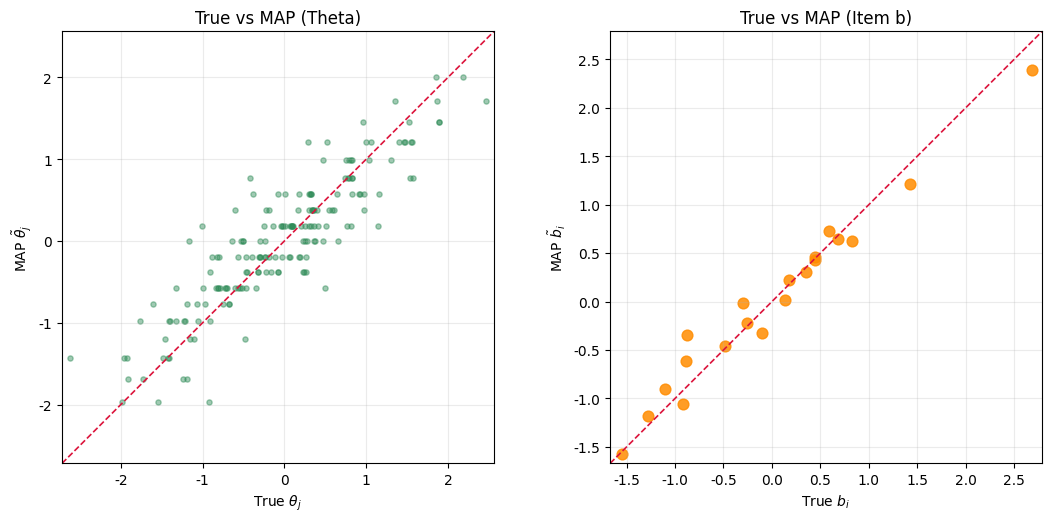

corr(theta_true, theta_map) = 0.890
corr(b_true,     b_map)     = 0.984


In [4]:
# Purpose: run MAP optimization as a fast point-estimation step before MCMC.
# Purpose: compare true parameters against MAP estimates on the logit scale.
map_fit = model.optimize(data=stan_data, seed=42)

# Extract MAP estimates
try:
    theta_map = np.asarray(map_fit.stan_variable('theta')).ravel()
    b_map = np.asarray(map_fit.stan_variable('b')).ravel()
except Exception:
    p = map_fit.optimized_params_dict
    theta_map = np.array([p[f'theta[{j}]'] for j in range(1, J + 1)])
    b_map = np.array([p[f'b[{i}]'] for i in range(1, I + 1)])

def _diag(ax, x, y, color='crimson'):
    lo = min(np.min(x), np.min(y)) - 0.1
    hi = max(np.max(x), np.max(y)) + 0.1
    ax.plot([lo, hi], [lo, hi], '--', color=color, lw=1.2)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect('equal', adjustable='box')

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))

axes[0].scatter(theta_true, theta_map, s=14, alpha=0.45, color='seagreen')
_diag(axes[0], theta_true, theta_map)
axes[0].set_title('True vs MAP (Theta)')
axes[0].set_xlabel('True $\\theta_j$')
axes[0].set_ylabel('MAP $\\tilde{\\theta}_j$')
axes[0].grid(alpha=0.25)

axes[1].scatter(b_true, b_map, s=60, alpha=0.85, color='darkorange')
_diag(axes[1], b_true, b_map)
axes[1].set_title('True vs MAP (Item b)')
axes[1].set_xlabel('True $b_i$')
axes[1].set_ylabel('MAP $\\tilde{b}_i$')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"corr(theta_true, theta_map) = {np.corrcoef(theta_true, theta_map)[0,1]:.3f}")
print(f"corr(b_true,     b_map)     = {np.corrcoef(b_true, b_map)[0,1]:.3f}")

## 5. Bayesian Inference via MCMC

We use **Hamiltonian Monte Carlo (HMC / NUTS)** via CmdStan. Four chains with 1000 warm-up and 1000 sampling iterations each.

In [5]:
# Purpose: run full Bayesian inference with NUTS/HMC sampling.
# Purpose: obtain posterior draws for person and item parameters.
fit = model.sample(
    data=stan_data,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42,
    show_progress=True
)
print(fit.diagnose())

15:15:04 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

15:15:25 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [6]:
# Purpose: extract posterior samples and compute posterior-mean estimates.
# Purpose: summarize recovery of true parameters by Bayesian estimation.
# Extract posterior samples
theta_post = fit.stan_variable('theta')   # shape: (4000, J)
b_post     = fit.stan_variable('b')       # shape: (4000, I)

theta_est = theta_post.mean(axis=0)
b_est     = b_post.mean(axis=0)

print("Item difficulty recovery (true vs posterior mean):")
print(f"{'Item':>6} {'True b':>10} {'Est b':>10} {'Error':>10}")
for i in range(I):
    print(f"{i+1:>6} {b_true[i]:>10.3f} {b_est[i]:>10.3f} {b_est[i]-b_true[i]:>10.3f}")

corr_b = np.corrcoef(b_true, b_est)[0, 1]
corr_theta = np.corrcoef(theta_true, theta_est)[0, 1]
print(f"\nCorrelation (true vs estimated): b = {corr_b:.3f},  theta = {corr_theta:.3f}")

Item difficulty recovery (true vs posterior mean):
  Item     True b      Est b      Error
     1      1.420      1.271     -0.149
     2     -0.298     -0.005      0.293
     3      2.687      2.501     -0.186
     4      0.592      0.768      0.176
     5     -0.891     -0.641      0.249
     6     -1.104     -0.938      0.167
     7      0.449      0.482      0.033
     8     -0.257     -0.225      0.032
     9      0.680      0.680     -0.000
    10      0.440      0.454      0.014
    11     -0.106     -0.330     -0.224
    12     -0.880     -0.359      0.522
    13     -1.548     -1.635     -0.086
    14     -0.480     -0.469      0.011
    15      0.823      0.653     -0.170
    16      0.181      0.235      0.054
    17     -1.279     -1.230      0.050
    18      0.140      0.021     -0.119
    19      0.352      0.316     -0.036
    20     -0.917     -1.094     -0.176

Correlation (true vs estimated): b = 0.984,  theta = 0.890


## 5. Visualizations

### 5a. Wright Map (Person–Item Map)

A **Wright map** (also called a person–item map) displays **person ability estimates** and **item difficulty estimates** on the same logit scale.

- **Left panel**: Histogram of estimated person abilities $\hat{\theta}_j$. The distribution shape reveals whether the test is well-targeted for this group.
- **Right panel**: Item difficulties $\hat{b}_i$ as tick marks. Easy items are at the bottom (low $b$), hard items at the top (high $b$).

**Interpretation**: If the person distribution is centred around $b \approx 0$, the test is well-targeted. Items whose $b$ falls outside the bulk of the $\theta$ distribution provide little information for most students.

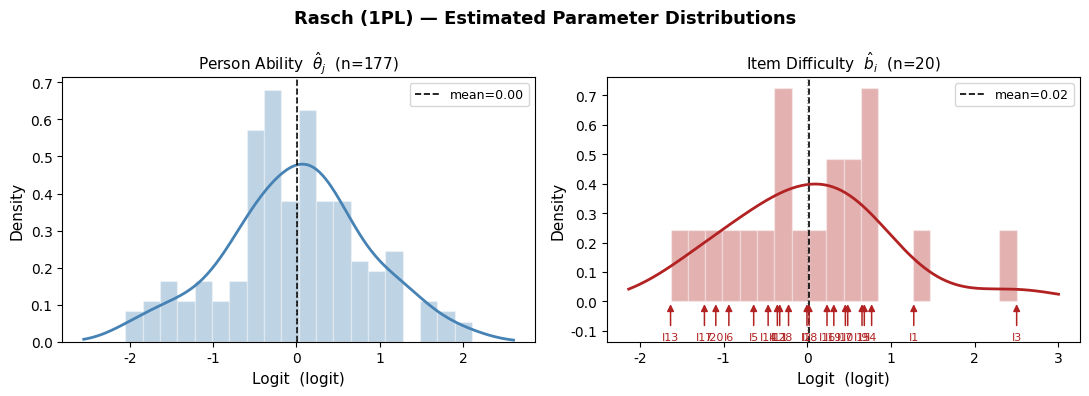

theta: mean=0.003  SD=0.850  range=[-2.05, 2.10]
b    : mean=0.023  SD=0.925  range=[-1.63, 2.50]


In [7]:
# Purpose: visualize posterior-mean distributions for person ability and item difficulty.
# Purpose: mark exact item locations with arrows on the item-density panel.
# ── Posterior Parameter Density (Logit Scale) ─────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Rasch (1PL) — Estimated Parameter Distributions', fontsize=13, fontweight='bold')

panels = [
    (axes[0], theta_est, r'Person Ability  $\hat{\theta}_j$',  'steelblue',  'logit'),
    (axes[1], b_est,     r'Item Difficulty  $\hat{b}_i$',       'firebrick',   'logit'),
]

for ax, vals, title, color, unit in panels:
    ax.hist(vals, bins=20, density=True, color=color, alpha=0.35, edgecolor='white')
    xs = np.linspace(vals.min() - 0.5, vals.max() + 0.5, 300)
    kde = gaussian_kde(vals, bw_method='scott')
    ax.plot(xs, kde(xs), color=color, linewidth=2)
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'mean={vals.mean():.2f}')
    ax.axvline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_xlabel(f'Logit  ({unit})', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{title}  (n={len(vals)})', fontsize=11)
    ax.legend(fontsize=9)

# Mark exact item locations on the right panel with arrows on the logit axis
ax_item = axes[1]
ymax = ax_item.get_ylim()[1]
for i, b in enumerate(b_est, start=1):
    ax_item.annotate('', xy=(b, 0), xytext=(b, -0.12 * ymax),
                     arrowprops=dict(arrowstyle='-|>', color='firebrick', lw=1.1),
                     annotation_clip=False)
    ax_item.text(b, -0.135 * ymax, f'I{i}', ha='center', va='top',
                 fontsize=8, color='firebrick', clip_on=False)
ax_item.set_ylim(-0.18 * ymax, ymax)

plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'density_rasch.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f"theta: mean={theta_est.mean():.3f}  SD={theta_est.std():.3f}  "
      f"range=[{theta_est.min():.2f}, {theta_est.max():.2f}]")
print(f"b    : mean={b_est.mean():.3f}  SD={b_est.std():.3f}  "
      f"range=[{b_est.min():.2f}, {b_est.max():.2f}]")

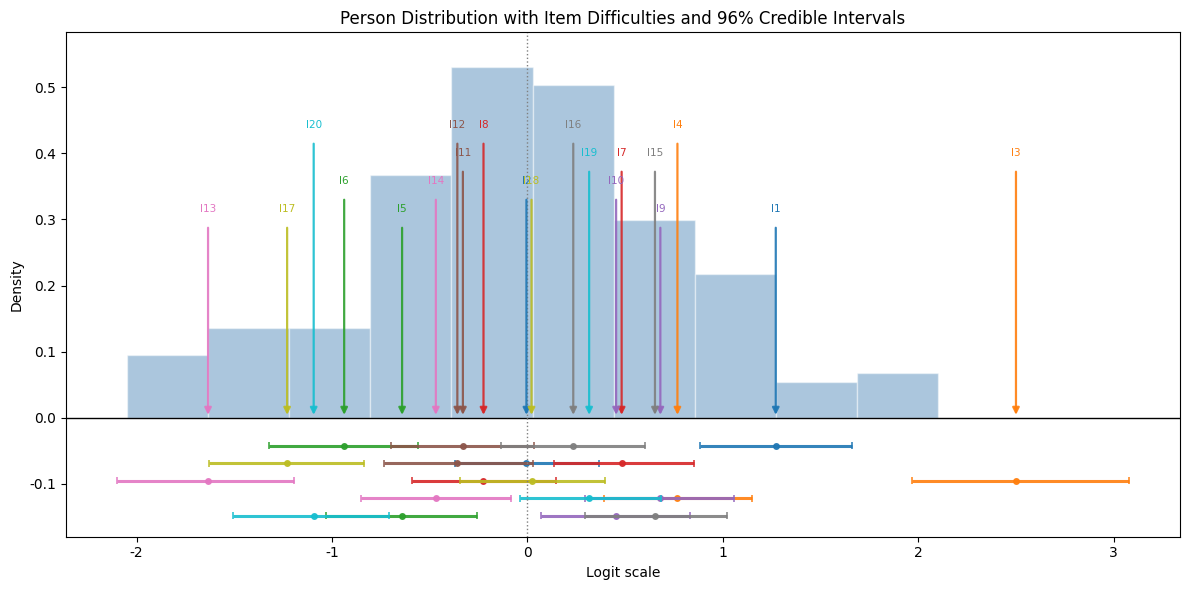

In [9]:
# Purpose: overlay person distribution with item locations and 96% credible intervals.
# Purpose: inspect item targeting and uncertainty on the shared logit scale.
# Person histogram on logit scale + item difficulty arrows + 96% credible intervals

theta_vals = theta_est if 'theta_est' in globals() else theta_true

if 'b_post' in globals():
    b_loc = b_post.mean(axis=0)
    b_ci_low, b_ci_high = np.quantile(b_post, [0.02, 0.98], axis=0)  # 96% CrI
else:
    b_loc = b_est if 'b_est' in globals() else b_true
    b_ci_low = b_loc - 0.2
    b_ci_high = b_loc + 0.2
    print("ℹ️ b_post not found: using placeholder intervals (±0.2).")

import matplotlib.cm as cm
item_colors = cm.tab10(np.linspace(0, 1, len(b_loc)))

fig, ax = plt.subplots(figsize=(12, 6))

# Histogram of person abilities
counts, bins, _ = ax.hist(
    theta_vals,
    bins=10,
    density=True,
    color='steelblue',
    alpha=0.45,
    edgecolor='white',
    label='Persons (ability)'
)

ymax = max(counts) if len(counts) > 0 else 1.0

# Item difficulty arrows (vertical, pointing to x-axis)
for i, x in enumerate(b_loc):
    y_start = ymax * (0.55 + 0.08 * (i % 4))
    ax.annotate(
        '',
        xy=(x, 0.0),
        xytext=(x, y_start),
        arrowprops=dict(arrowstyle='-|>', color=item_colors[i], lw=1.6, alpha=0.9)
    )
    ax.text(x, y_start + ymax * 0.03, f'I{i+1}', ha='center', va='bottom',
            fontsize=7.5, color=item_colors[i])

# 96% credible intervals for item parameters (drawn below x-axis)
ci_levels = -ymax * (0.08 + 0.05 * (np.arange(len(b_loc)) % 5))
for i in range(len(b_loc)):
    y_ci = ci_levels[i]
    c = item_colors[i]
    ax.hlines(y_ci, b_ci_low[i], b_ci_high[i], color=c, lw=2.2, alpha=0.9)
    ax.vlines([b_ci_low[i], b_ci_high[i]], y_ci - ymax * 0.01, y_ci + ymax * 0.01,
              color=c, lw=1.2, alpha=0.9)
    ax.plot(b_loc[i], y_ci, 'o', color=c, markersize=4, alpha=0.9)

ax.axhline(0, color='black', lw=1)
ax.axvline(0, color='gray', linestyle=':', lw=1)

ax.set_xlabel('Logit scale')
ax.set_ylabel('Density')
ax.set_title('Person Distribution with Item Difficulties and 96% Credible Intervals')
ax.set_ylim(ci_levels.min() - ymax * 0.06, ymax * 1.1)

plt.tight_layout()
plt.show()

### 5b. Item Difficulty distributions


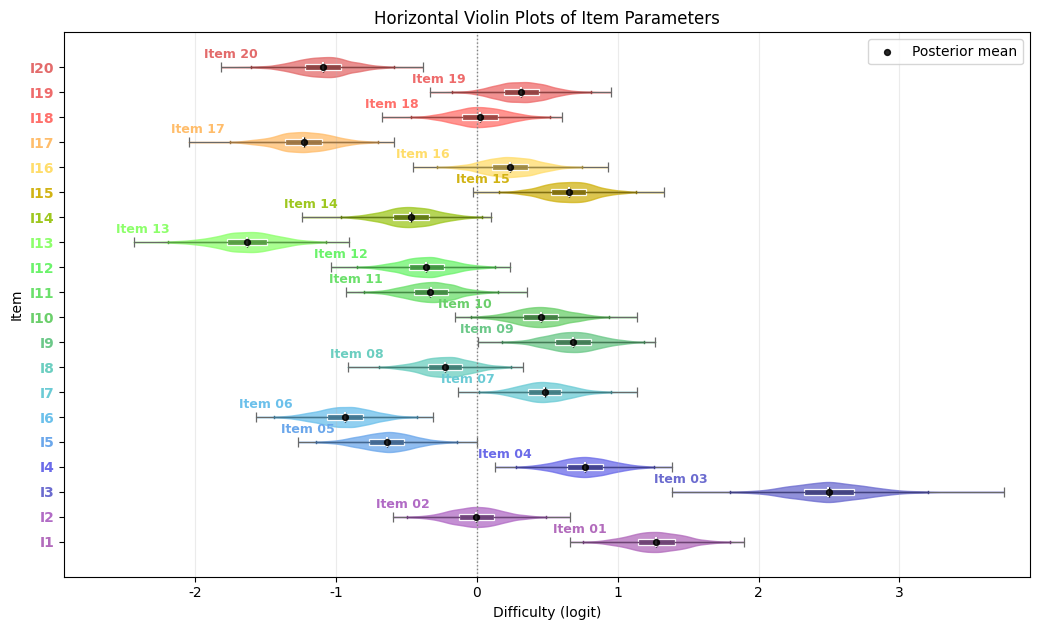

In [34]:
# Purpose: show horizontal violin plots for item difficulty posteriors.
# Purpose: assign a distinct color to each item violin and its matching item label.
# Horizontal violin plots for item difficulty parameters

if 'b_post' in globals():
    item_samples = b_post  # (draws, I)
elif 'fit' in globals():
    item_samples = fit.stan_variable('b')
else:
    center = b_est if 'b_est' in globals() else b_true
    item_samples = np.random.normal(loc=center, scale=0.15, size=(2000, len(center)))
    print("ℹ️ b_post not found: using proxy draws around b_est/b_true.")

n_items = item_samples.shape[1]
positions = np.arange(1, n_items + 1)
base_colors = plt.cm.nipy_spectral(np.linspace(0.06, 0.94, n_items))
plot_colors = 0.58 * base_colors[:, :3] + 0.42 * np.ones((n_items, 3))

# Manually deepen low-contrast yellow tones for Item 14 and Item 15.
if n_items >= 15:
    plot_colors[13] = np.array([0.62, 0.78, 0.12])
    plot_colors[14] = np.array([0.82, 0.70, 0.08])

dark_box_colors = np.clip(0.62 * plot_colors, 0, 1)

fig, ax = plt.subplots(figsize=(10.5, 6.4))

vp = ax.violinplot(
    [item_samples[:, i] for i in range(n_items)],
    positions=positions,
    vert=False,
    widths=0.8,
    showmeans=True,
    showmedians=True,
    showextrema=True
)

for i, body in enumerate(vp['bodies']):
    body.set_facecolor(plot_colors[i])
    body.set_edgecolor(plot_colors[i])
    body.set_alpha(0.75)
    body.set_linewidth(1.0)

# Add compact horizontal boxplots inside each violin using darker matching colors.
bp = ax.boxplot(
    [item_samples[:, i] for i in range(n_items)],
    positions=positions,
    vert=False,
    widths=0.22,
    patch_artist=True,
    showfliers=False,
    manage_ticks=False,
    zorder=3
)

for i, box in enumerate(bp['boxes']):
    box.set_facecolor(dark_box_colors[i])
    box.set_alpha(0.95)
    box.set_edgecolor('white')
    box.set_linewidth(0.9)

for median in bp['medians']:
    median.set_color('white')
    median.set_linewidth(1.4)

for i, whisker in enumerate(bp['whiskers']):
    whisker.set_color(dark_box_colors[i // 2])
    whisker.set_linewidth(1.0)

for i, cap in enumerate(bp['caps']):
    cap.set_color(dark_box_colors[i // 2])
    cap.set_linewidth(1.0)

vp['cmeans'].set_color('black')
vp['cmeans'].set_linewidth(1.0)
vp['cmedians'].set_color('white')
vp['cmedians'].set_linewidth(1.4)
vp['cbars'].set_color('dimgray')
vp['cbars'].set_linewidth(0.9)
vp['cmins'].set_color('dimgray')
vp['cmins'].set_linewidth(0.9)
vp['cmaxes'].set_color('dimgray')
vp['cmaxes'].set_linewidth(0.9)

x_min = np.min(item_samples)
x_max = np.max(item_samples)
x_pad = 0.08 * (x_max - x_min + 1e-9)

for i, y0 in enumerate(positions, start=1):
    x_left = np.min(item_samples[:, i - 1])
    ax.text(
        x_left - 0.25 * x_pad,
        y0 + 0.24,
        f'Item {i:02d}',
        ha='left',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color=plot_colors[i - 1]
    )

ax.set_xlim(x_min - x_pad, x_max + 0.03 * (x_max - x_min + 1e-9))

if 'b_est' in globals() and len(b_est) == n_items:
    ax.scatter(b_est, positions, color='black', s=18, alpha=0.85, label='Posterior mean', zorder=4)

ax.set_yticks(positions)
ax.set_yticklabels([f'I{i}' for i in positions])
for tick_label, color in zip(ax.get_yticklabels(), plot_colors):
    tick_label.set_color(color)
    tick_label.set_fontweight('bold')

ax.set_xlabel('Difficulty (logit)')
ax.set_ylabel('Item')
ax.set_title('Horizontal Violin Plots of Item Parameters')
ax.axvline(0, color='gray', linestyle=':', linewidth=1)
ax.grid(axis='x', alpha=0.25)
ax.legend(loc='best')

plt.tight_layout()
plt.show()

### 5c. True Item parameters and Posterior Distributions

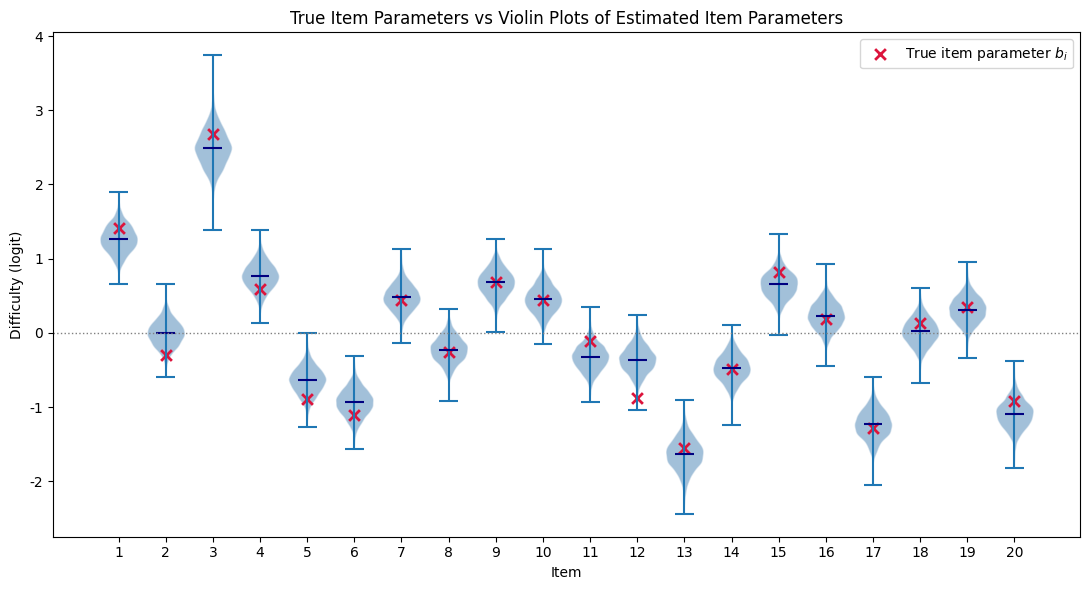

In [35]:
# Purpose: compare true item parameters with posterior item distributions.
# Purpose: visualize recovery quality using violin plots for each item.
# True item parameters vs posterior violin plots

if 'b_post' in globals():
    item_samples = b_post  # shape: (draws, I)
elif 'fit' in globals():
    item_samples = fit.stan_variable('b')
else:
    print("ℹ️ b_post not found: Cannot proceed with violin plots.")
    item_samples = None

n_items = len(b_true)
positions = np.arange(1, n_items + 1)

fig, ax = plt.subplots(figsize=(11, 6))

vp = ax.violinplot(
    [item_samples[:, i] for i in range(n_items)],
    positions=positions,
    showmeans=False,
    showmedians=True,
    widths=0.8
)

for body in vp['bodies']:
    body.set_facecolor('steelblue')
    body.set_edgecolor('white')
    body.set_alpha(0.5)

vp['cmedians'].set_color('navy')
vp['cmedians'].set_linewidth(1.5)

ax.scatter(
    positions, b_true,
    color='crimson', marker='x', s=60, linewidths=2,
    label='True item parameter $b_i$'
)

ax.set_xticks(positions)
ax.set_xlabel('Item')
ax.set_ylabel('Difficulty (logit)')
ax.set_title('True Item Parameters vs Violin Plots of Estimated Item Parameters')
ax.axhline(0, color='gray', linestyle=':', linewidth=1)
ax.legend(loc='best')

plt.tight_layout()
plt.show()

### 5d. True vs Posterior Person Parameter Distribution

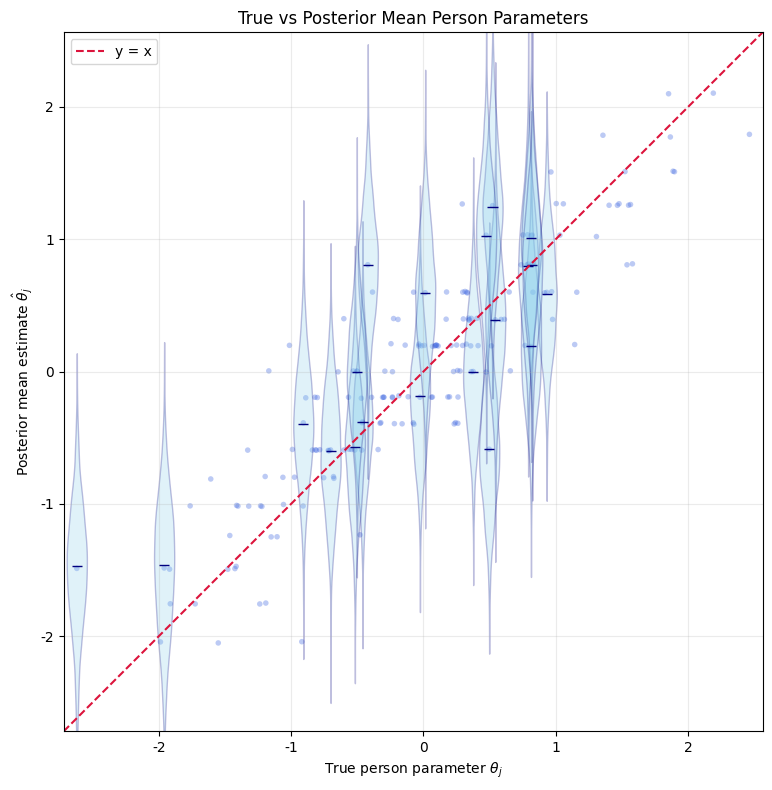

In [12]:
# Purpose: compare true person parameters with posterior mean estimates.
# Purpose: add posterior-violin overlays to inspect uncertainty and recovery.
# True person parameters vs posterior mean estimates (with diagonal + posterior violins)

if 'theta_true' not in globals() or 'theta_est' not in globals():
    raise ValueError("theta_true and/or theta_est not found in notebook variables.")

# Get posterior draws if needed
if 'theta_post' not in globals() and 'fit' in globals():
    theta_post = fit.stan_variable('theta')  # shape: (draws, J)

fig, ax = plt.subplots(figsize=(8, 8))

# Scatter: true vs posterior mean
ax.scatter(theta_true, theta_est, s=16, alpha=0.35, color='royalblue', edgecolor='none')

# Optional violin plots for posterior distributions (subset for readability)
if 'theta_post' in globals() and theta_post.shape[1] == len(theta_true):
    max_violin = 20
    idx = np.linspace(0, len(theta_true) - 1, max_violin, dtype=int)
    pos = theta_true[idx]
    samples = [theta_post[:, i] for i in idx]

    width = 0.03 * (theta_true.max() - theta_true.min() + 1e-9)
    vp = ax.violinplot(
        samples,
        positions=pos,
        widths=width,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )
    for body in vp['bodies']:
        body.set_facecolor('skyblue')
        body.set_edgecolor('navy')
        body.set_alpha(0.25)
    vp['cmedians'].set_color('navy')
    vp['cmedians'].set_linewidth(1.0)
else:
    print("ℹ️ theta_post not found: violin plots skipped.")

# Diagonal reference line
lo = min(theta_true.min(), theta_est.min()) - 0.1
hi = max(theta_true.max(), theta_est.max()) + 0.1
ax.plot([lo, hi], [lo, hi], '--', color='crimson', linewidth=1.5, label='y = x')

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('True person parameter $\\theta_j$')
ax.set_ylabel('Posterior mean estimate $\\hat{\\theta}_j$')
ax.set_title('True vs Posterior Mean Person Parameters')
ax.grid(alpha=0.25)
ax.legend(loc='best')

plt.tight_layout()
plt.show()